In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])


c:\Users\Greg\anaconda3\envs\Python_Data_Project_1_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Lets create the dataframes first
# Sample dataset of job postings in February
job_postings_jan = pd.DataFrame({
    'job_id': [1, 2, 3, 4, 5],
    'job_title': ['Data Scientist', 'Data Analyst', 'Machine Learning Engineer', 'Data Scientist', 'Data Engineer'],
    'company': ['Company A', 'Company B', 'Company C', 'Company D', 'Company E'],
    'job_posted_date': pd.to_datetime(['2024-01-02', '2024-01-07', '2024-01-14', '2024-01-19', '2024-01-24'])
})

job_postings_jan

,job_id,job_title,company,job_posted_date
0,1,Data Scientist,Company A,2024-01-02
1,2,Data Analyst,Company B,2024-01-07
2,3,Machine Learning Engineer,Company C,2024-01-14
3,4,Data Scientist,Company D,2024-01-19
4,5,Data Engineer,Company E,2024-01-24


In [3]:
# Sample dataset of job postings in February
job_postings_feb = pd.DataFrame({
    'job_id': [6, 7, 8, 9, 10],
    'job_title': ['Data Scientist', 'Data Analyst', 'Machine Learning Engineer', 'Data Scientist', 'Data Engineer'],
    'company': ['Company F', 'Company G', 'Company H', 'Company I', 'Company J'],
    'job_posted_date': pd.to_datetime(['2024-02-05', '2024-02-09', '2024-02-12', '2024-02-18', '2024-02-22'])
})
job_postings_feb

,job_id,job_title,company,job_posted_date
0,6,Data Scientist,Company F,2024-02-05
1,7,Data Analyst,Company G,2024-02-09
2,8,Machine Learning Engineer,Company H,2024-02-12
3,9,Data Scientist,Company I,2024-02-18
4,10,Data Engineer,Company J,2024-02-22


In [4]:
# Concatenate the two DataFrames
pd.concat([job_postings_jan, job_postings_feb], ignore_index=True) #list of the dataframes inside of pandas method


,job_id,job_title,company,job_posted_date
0,1,Data Scientist,Company A,2024-01-02
1,2,Data Analyst,Company B,2024-01-07
2,3,Machine Learning Engineer,Company C,2024-01-14
3,4,Data Scientist,Company D,2024-01-19
4,5,Data Engineer,Company E,2024-01-24
5,6,Data Scientist,Company F,2024-02-05
6,7,Data Analyst,Company G,2024-02-09
7,8,Machine Learning Engineer,Company H,2024-02-12
8,9,Data Scientist,Company I,2024-02-18
9,10,Data Engineer,Company J,2024-02-22


Example 2

Now looking at our dataset. Similarly to the last section, let's filter for Data Analysts and then create a column for the month. Then we'll filter for March and April job postings and concatenate these two.

Note: This problem is only for demonstration purposes it's not very useful right now.

In [5]:
df.sample(3)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
140592,Senior Data Engineer,Engenheiro de dados senior,Anywhere,via LinkedIn,Full-time,True,Brazil,2023-09-22 08:42:51,True,False,Brazil,NaN,NaN,NaN,Netvagas,NaN,NaN
48848,Senior Data Scientist,Senior Data Scientist (ML / AI) - RCCB - Now H...,"Niles, IL",via Snagajob,Full-time,False,"Illinois, United States",2023-05-01 06:06:46,False,False,United States,NaN,NaN,NaN,Reyes Coca-Cola Bottling,"['sql', 'python', 'r', 'snowflake', 'databrick...","{'cloud': ['snowflake', 'databricks', 'azure']..."
509891,Data Analyst,(Senior) Data Analyst,"Kuala Lumpur, Federal Territory of Kuala Lumpu...",via Ricebowl,Full-time,False,Malaysia,2023-05-12 11:49:58,False,False,Malaysia,NaN,NaN,NaN,Accenture,"['sql', 'python', 'sql server', 'azure', 'expr...","{'cloud': ['azure'], 'databases': ['sql server..."


In [6]:
df['job_posted_month']  = df['job_posted_date'].dt.strftime('%b')
df.sample(3)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
748659,Data Scientist,System Test Analyst / Data Scientist - Clearan...,Colorado,via LinkedIn,Full-time,False,"Texas, United States",2023-03-21 20:22:09,True,False,United States,NaN,NaN,NaN,Lockheed Martin,NaN,NaN,Mar
291286,Data Scientist,Data Scientist,Anywhere,via Indeed,Full-time,True,Georgia,2023-03-07 18:18:11,False,True,United States,year,140000.0,NaN,Datawiz Corporation,"['r', 'python', 'julia', 'pytorch', 'keras', '...","{'libraries': ['pytorch', 'keras', 'tensorflow...",Mar
61083,Data Engineer,Data Engineer Ssr/Sr,"Buenos Aires, Argentina",via LinkedIn,Full-time,False,Argentina,2023-10-19 07:08:46,True,False,Argentina,NaN,NaN,NaN,COA Tecnología,"['sql', 'python', 'sql server', 'numpy', 'pand...","{'databases': ['sql server'], 'libraries': ['n...",Oct


In [7]:
months = df['job_posted_month'].unique()
months

<ArrowStringArray>
['Jun', 'Jan', 'Oct', 'Jul', 'Aug', 'Nov', 'Mar', 'Dec', 'Apr', 'Feb', 'Sep',
 'May']
Length: 12, dtype: str

In [8]:
# write this with dict comprehension
dict_months = {month: df[df['job_posted_month'] == month] for month in months}

# long way
# dict_months = {}
# for month in months:
#     dict_months[month] = df[df['job_posted_month'] == month]

type(dict_months)

dict

In [9]:
dict_months['Jan'].sample(10)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
446137,Data Engineer,Lead Data Engineer,Anywhere,via LinkedIn,Full-time,True,Mexico,2023-01-11 16:20:04,False,False,Mexico,NaN,NaN,NaN,Luxoft,"['python', 'sql', 'shell', 'azure', 'aws', 'ha...","{'analyst_tools': ['tableau'], 'cloud': ['azur...",Jan
517027,Senior Data Scientist,Senior Data Scientist,"Phoenix, AZ",via BeBee,Full-time,False,"California, United States",2023-01-26 11:05:50,False,True,United States,NaN,NaN,NaN,Oracle,"['go', 'oracle']","{'cloud': ['oracle'], 'programming': ['go']}",Jan
7333,Data Analyst,Ausbildung: Data Analyst (w/m/d),"Munich, Germany",via KSNT Jobs,Full-time,False,Germany,2023-01-15 13:20:01,True,False,Germany,NaN,NaN,NaN,Siemens AG,NaN,NaN,Jan
779091,Data Analyst,Business Data Analyst,Singapore,via BeBee Singapore,Full-time,False,Singapore,2023-01-21 06:13:57,False,False,Singapore,NaN,NaN,NaN,Quess Corp Limited,['sql'],{'programming': ['sql']},Jan
329574,Senior Data Engineer,Senior Data Engineer,"Manchester, UK",via KPMG Careers,Full-time,False,United Kingdom,2023-01-13 23:16:32,True,False,United Kingdom,NaN,NaN,NaN,KPMG UK,"['sql', 'sql server', 'azure', 'databricks', '...","{'analyst_tools': ['power bi', 'alteryx', 'qli...",Jan
371197,Business Analyst,"Senior Associate, Data Governance Business Ana...",Australia,via Jobrapido.com,Full-time,False,Australia,2023-01-06 23:34:45,False,False,Australia,NaN,NaN,NaN,Macquarie Group,NaN,NaN,Jan
591796,Senior Data Engineer,Senior Database Engineer,"Turku, Finland",via LinkedIn Finland,Full-time,False,Finland,2023-01-16 10:18:57,False,False,Finland,NaN,NaN,NaN,Verve Group,"['java', 'c++', 'python', 'go', 'javascript', ...","{'databases': ['postgresql', 'redis', 'elastic...",Jan
578443,Data Analyst,Data Analytics - Performance Analyst,"Cebu City, Cebu, Philippines",via Indeed,Full-time,False,Philippines,2023-01-11 09:15:59,False,False,Philippines,NaN,NaN,NaN,Community Minerals,"['excel', 'spreadsheet', 'sheets']","{'analyst_tools': ['excel', 'spreadsheet', 'sh...",Jan
77187,Data Engineer,Data Engineer,"Lille, France",via Recruit.net,Full-time,False,France,2023-01-12 00:14:32,True,False,France,NaN,NaN,NaN,Amaris,['spark'],{'libraries': ['spark']},Jan
522308,Software Engineer,Software Engineer,"Hasselt, Belgium",via BeBee Belgique,Full-time,False,Belgium,2023-01-24 11:26:34,False,False,Belgium,NaN,NaN,NaN,Key Technology,"['c++', 'python', 'qt', 'linux']","{'libraries': ['qt'], 'os': ['linux'], 'progra...",Jan


In [10]:
#Concatenate the first quarter

quarter_1 = [dict_months['Jan'], dict_months['Feb'], dict_months['Mar']]

df_q1 = pd.concat(quarter_1, ignore_index=True)

df_q1.sample(10)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
33622,Data Analyst,WFP recruits 01 Data Analyste.,"Dakar, Senegal",via WhatJobs,NaN,False,Senegal,2023-01-26 23:54:26,False,False,Senegal,NaN,NaN,NaN,WFP,"['c', 'tableau', 'power bi', 'sharepoint']","{'analyst_tools': ['tableau', 'power bi', 'sha...",Jan
53725,Senior Data Scientist,Sr. Manager Customer Insights & Data Analytics...,U.S. Virgin Islands,via SimplyHired,Full-time,False,U.S. Virgin Islands,2023-01-18 11:56:25,False,False,U.S. Virgin Islands,NaN,NaN,NaN,Ryder System,"['sql', 'python', 'r', 'databricks', 'excel']","{'analyst_tools': ['excel'], 'cloud': ['databr...",Jan
25358,Cloud Engineer,Senior Lead Cloud Database Engineer,"Guadalajara, Jalisco, Mexico",via LinkedIn,Full-time,False,Mexico,2023-01-21 07:27:21,False,False,Mexico,NaN,NaN,NaN,NTT DATA Services,"['powershell', 't-sql', 'oracle', 'azure', 'aws']","{'cloud': ['oracle', 'azure', 'aws'], 'program...",Jan
190124,Data Analyst,Data Analyst (Mobile Growth),"Bonita Springs, FL",via LinkedIn,Full-time,False,Georgia,2023-03-31 17:11:12,True,True,United States,NaN,NaN,NaN,ReachMobi,"['sql', 'excel']","{'analyst_tools': ['excel'], 'programming': ['...",Mar
172488,Senior Data Engineer,Senior Data Engineer,"Vienna, Austria",via BeBee,Full-time,False,Austria,2023-03-09 15:38:53,False,False,Austria,NaN,NaN,NaN,TransUnion,"['go', 'sql', 'python', 'aws', 'redshift', 'ha...","{'analyst_tools': ['tableau'], 'cloud': ['aws'...",Mar
32134,Data Engineer,Data Engineer,"Durham, NC",via LinkedIn,Contractor,False,"Florida, United States",2023-01-01 23:28:37,False,False,United States,NaN,NaN,NaN,Mindteck,"['shell', 'oracle', 'aws', 'snowflake', 'redsh...","{'analyst_tools': ['excel'], 'cloud': ['oracle...",Jan
67858,Data Analyst,Data Analyst,"Lyon, France",via LinkedIn,Full-time,False,France,2023-01-20 12:37:37,False,False,France,NaN,NaN,NaN,k-ciopé,"['sql', 'python', 'excel']","{'analyst_tools': ['excel'], 'programming': ['...",Jan
135384,Data Engineer,Big Data Engineer,"Pimpri-Chinchwad, Maharashtra, India",via LinkedIn,Full-time,False,India,2023-02-07 11:13:29,True,False,India,NaN,NaN,NaN,ESSENWARE PRIVATE LIMITED,"['sql', 'scala', 'hadoop', 'spark', 'kafka', '...","{'libraries': ['hadoop', 'spark', 'kafka'], 'o...",Feb
28263,Data Scientist,NTT Data,"Brussels, Belgium",via BeBee Belgique,Full-time,False,Belgium,2023-01-19 18:12:03,False,False,Belgium,NaN,NaN,NaN,NTT Data,NaN,NaN,Jan
9981,Data Engineer,Cloud Data Engineer - Local Dallas,"Dallas, TX",via SimplyHired,Full-time,False,"Texas, United States",2023-01-27 00:10:40,True,False,United States,NaN,NaN,NaN,Slalom Consulting,"['sql', 'aws', 'azure', 'gcp', 'snowflake', 'r...","{'analyst_tools': ['tableau'], 'cloud': ['aws'...",Jan


<Axes: xlabel='job_posted_month'>

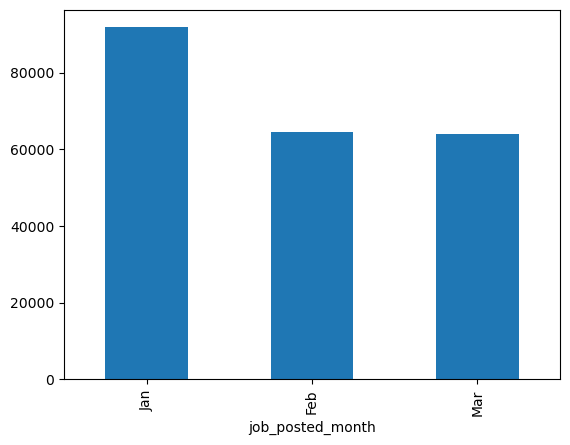

In [11]:
#Plot graph to confirm
df_q1['job_posted_month'].value_counts().plot(kind='bar')